# EDA

Cleaned Dataset Analysis
- 425K+ records across states and areas
- AQI values and quality status distributions
- Temporal and geographic patterns
- Pollutant analysis by region

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('../Data/processed/clean_data.csv')
print(f"Shape ->> {data.shape}")
print(f"\nColumns ->> {data.columns.tolist()}")
print(f"\nFirst few rows:")
print(data.head())

Shape ->> (425279, 13)

Columns ->> ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'year', 'month', 'day', 'day_of_week', 'quality_level']

First few rows:
         date           state       area  number_of_monitoring_stations  \
0  2025-06-19   uttar pradesh       agra                            5.0   
1  2025-06-19       karnataka   bagalkot                            1.0   
2  2025-06-19     maharashtra      akola                            1.0   
3  2025-06-19       rajasthan      alwar                            1.0   
4  2025-06-19  andhra pradesh  amaravati                            1.0   

  prominent_pollutants  aqi_value air_quality_status  \
0        O3,PM2.5,PM10         49               Good   
1                 PM10         46               Good   
2                 PM10         26               Good   
3                   CO         76       Satisfactory   
4                 PM10         66 

In [2]:

print("<<<--- Dataset Overview -->>>\n")
print(data.info())
print("<<-- Missing values -->>\n")
print(data.isnull().sum())


<<<--- Dataset Overview -->>>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425279 entries, 0 to 425278
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           425279 non-null  object 
 1   state                          425279 non-null  object 
 2   area                           425279 non-null  object 
 3   number_of_monitoring_stations  425138 non-null  float64
 4   prominent_pollutants           425279 non-null  object 
 5   aqi_value                      425279 non-null  int64  
 6   air_quality_status             425279 non-null  object 
 7   unit                           425279 non-null  object 
 8   year                           425279 non-null  int64  
 9   month                          425279 non-null  int64  
 10  day                            425279 non-null  int64  
 11  day_of_week                    425279 non-null  object 
 12 

In [3]:

print("\n<<--Numeric summ.-->>")
print(data[['aqi_value', 'number_of_monitoring_stations']].describe())


<<--Numeric summ.-->>
           aqi_value  number_of_monitoring_stations
count  425279.000000                  425138.000000
mean      118.664510                       1.826960
std        79.492278                       3.139322
min         3.000000                       1.000000
25%        61.000000                       1.000000
50%        96.000000                       1.000000
75%       152.000000                       1.000000
max       500.000000                      40.000000


In [4]:
print("<<<---- Air Quality Status Distribution -->>>")
print(data['air_quality_status'].value_counts())
print("\n<<---- Percentage ->>>")

c = data['air_quality_status'].value_counts()

Total = len(data)
per = (c / Total) * 100

print(per.round(2))

<<<---- Air Quality Status Distribution -->>>
air_quality_status
Satisfactory    155222
Moderate        138532
Good             69754
Poor             43812
Very Poor        15392
Severe            2567
Name: count, dtype: int64

<<---- Percentage ->>>
air_quality_status
Satisfactory    36.50
Moderate        32.57
Good            16.40
Poor            10.30
Very Poor        3.62
Severe           0.60
Name: count, dtype: float64


## Air Quality Status Distribution

## Visualization 1

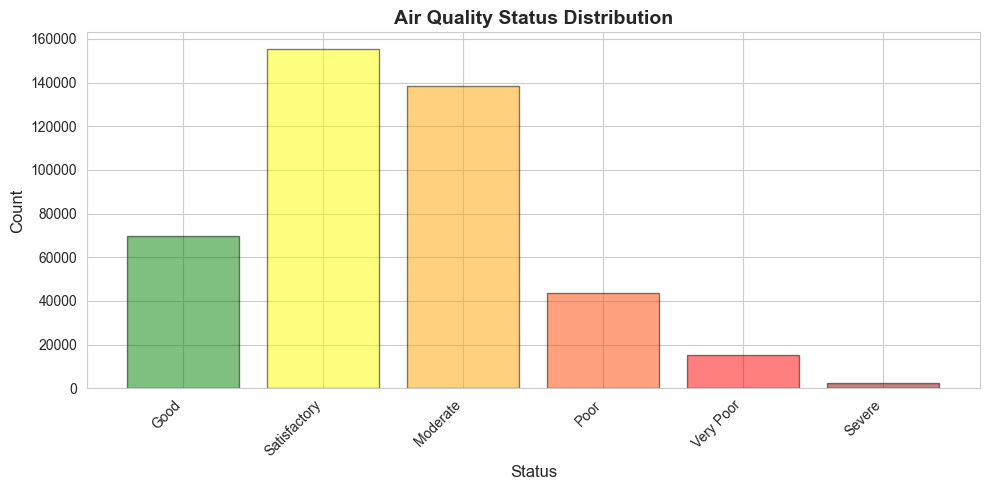

<<--- Count Status --->>
  Good: 69,754
  Satisfactory: 155,222
  Moderate: 138,532
  Poor: 43,812
  Very Poor: 15,392
  Severe: 2,567


In [7]:
status = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
status_counts = data['air_quality_status'].value_counts().reindex(status)

plt.figure(figsize=(10, 5))
colors = ['green', 'yellow', 'orange', 'orangered', 'red', 'darkred']
plt.bar(status, status_counts.values, color=colors, alpha=0.5, edgecolor='black')
plt.title("Air Quality Status Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("<<--- Count Status --->>")
for s, count in zip(status, status_counts.values):
    print(f"  {s}: {count:,}")

## Visualization 2 - AQI Value Distribution

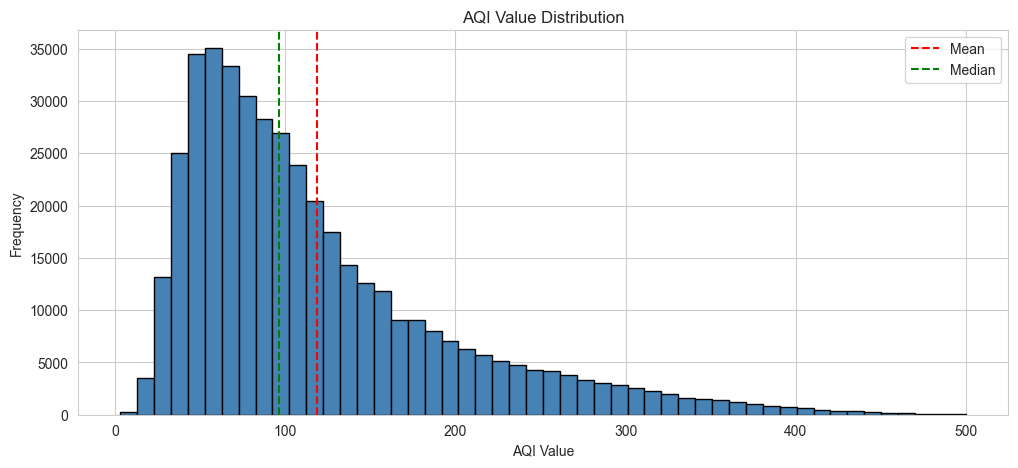

Mean: 118.66
Median: 96.00
Std Dev: 79.49


In [5]:
# Simple histogram with mean and median
plt.figure(figsize=(12, 5))
plt.hist(data['aqi_value'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(data['aqi_value'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data['aqi_value'].median(), color='green', linestyle='--', label='Median')
plt.title("AQI Value Distribution")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Print statistics
print(f"Mean: {data['aqi_value'].mean():.2f}")
print(f"Median: {data['aqi_value'].median():.2f}")
print(f"Std Dev: {data['aqi_value'].std():.2f}")

## Visualization 3 - Top 15 States by Average AQI

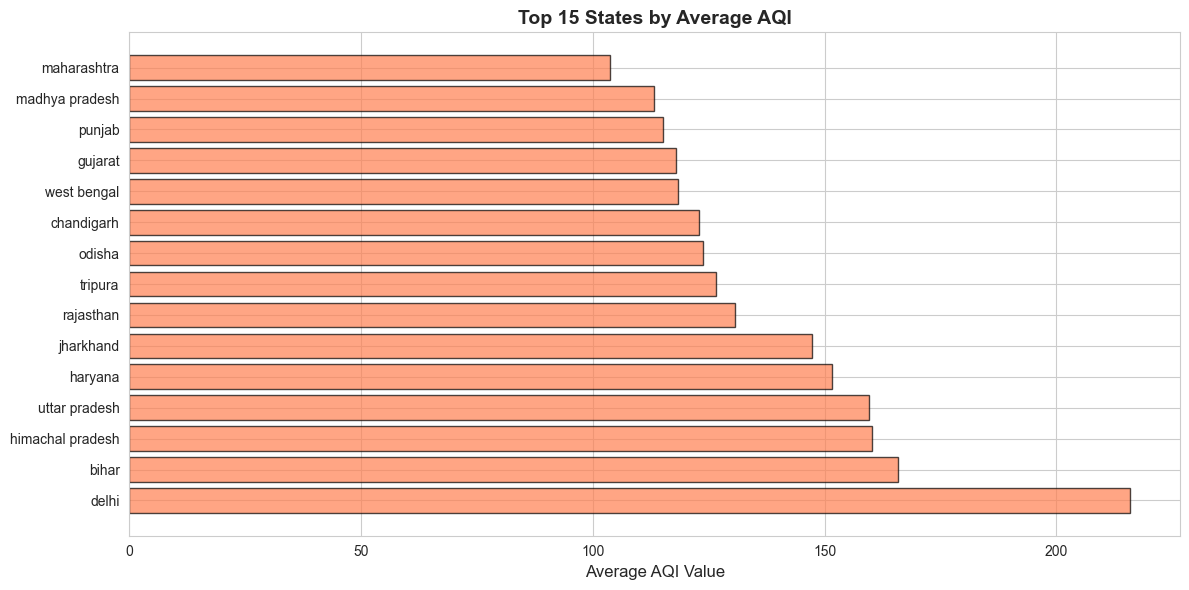

Top 15 States by Average AQI:
state
delhi               215.895080
bihar               165.905256
himachal pradesh    160.133040
uttar pradesh       159.542288
haryana             151.533731
jharkhand           147.367081
rajasthan           130.720200
tripura             126.565670
odisha              123.680314
chandigarh          122.829909
west bengal         118.290586
gujarat             118.018379
punjab              115.075731
madhya pradesh      113.111504
maharashtra         103.659658
Name: aqi_value, dtype: float64


In [7]:
state_aqi = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(state_aqi.index, state_aqi.values, color='coral', edgecolor='black', alpha=0.7)
plt.title("Top 15 States by Average AQI", fontsize=14, fontweight='bold')
plt.xlabel("Average AQI Value", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 15 States by Average AQI:")
print(state_aqi)

## Visualization 4 - Box Plot by Quality Status

C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_24256\2960769190.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, palette='Set2')


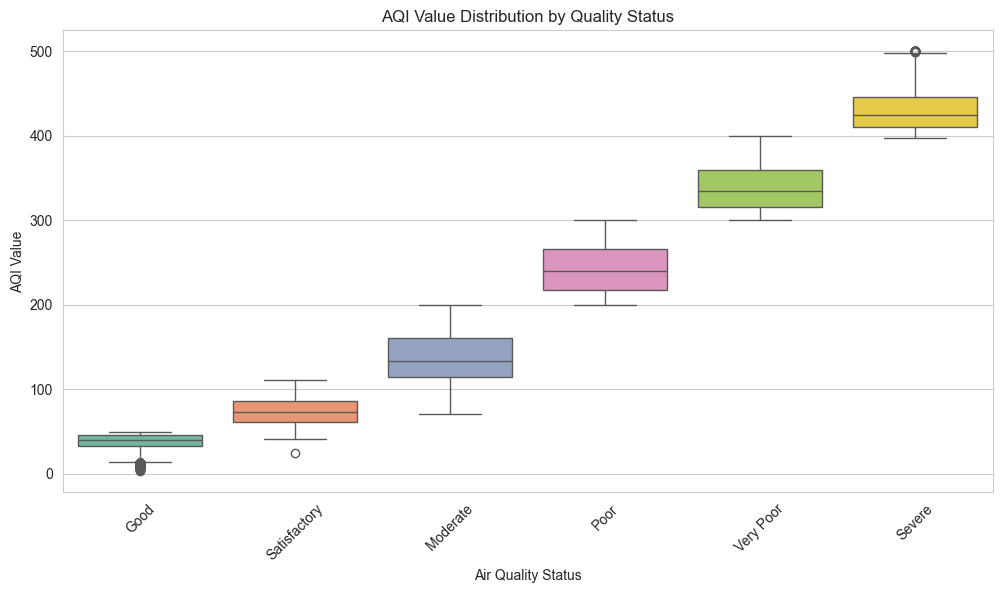


<<--- AQI Statistics by Quality Status --->>

GOOD:
  Count: 69,754
  Min: 3.00
  Q1 (25%): 33.00
  Median: 40.00
  Q3 (75%): 46.00
  Max: 50.00
  Mean: 38.53

SATISFACTORY:
  Count: 155,222
  Min: 25.00
  Q1 (25%): 62.00
  Median: 73.00
  Q3 (75%): 86.00
  Max: 111.00
  Mean: 74.12

MODERATE:
  Count: 138,532
  Min: 71.00
  Q1 (25%): 115.00
  Median: 134.00
  Q3 (75%): 161.00
  Max: 200.00
  Mean: 139.21

POOR:
  Count: 43,812
  Min: 200.00
  Q1 (25%): 218.00
  Median: 240.00
  Q3 (75%): 266.00
  Max: 300.00
  Mean: 243.29

VERY POOR:
  Count: 15,392
  Min: 300.00
  Q1 (25%): 316.00
  Median: 335.00
  Q3 (75%): 360.00
  Max: 400.00
  Mean: 339.39

SEVERE:
  Count: 2,567
  Min: 398.00
  Q1 (25%): 411.00
  Median: 425.00
  Q3 (75%): 446.00
  Max: 500.00
  Mean: 430.65


In [ ]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
data_sorted = data.copy()
data_sorted['air_quality_status'] = pd.Categorical(data_sorted['air_quality_status'], categories=status_order, ordered=True)
data_sorted = data_sorted.sort_values('air_quality_status')

plt.figure(figsize=(12, 6))
sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, palette='Set2')
plt.title("AQI Value Distribution by Quality Status")
plt.xlabel("Air Quality Status")
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
plt.show()

print("\n<<--- AQI Statistics by Quality Status --->>")
for status in status_order:
    subset = data[data['air_quality_status'] == status]['aqi_value']
    print(f"\n{status.upper()}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Min: {subset.min():.2f}")
    print(f"  Q1 (25%): {subset.quantile(0.25):.2f}")
    print(f"  Median: {subset.median():.2f}")
    print(f"  Q3 (75%): {subset.quantile(0.75):.2f}")
    print(f"  Max: {subset.max():.2f}")
    print(f"  Mean: {subset.mean():.2f}")

## Visualization 5 - Monthly Trends

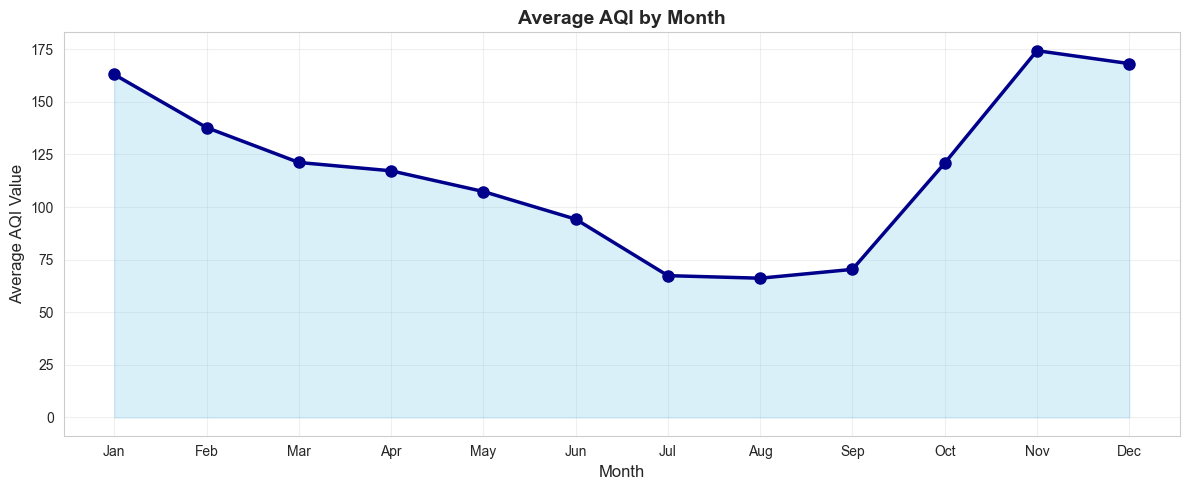

Average AQI by Month:
             mean  count
month                   
1      162.985960  37036
2      137.772164  34775
3      121.170215  38980
4      117.209994  36963
5      107.359033  38275
6       94.231228  34892
7       67.372855  32168
8       66.157212  32682
9       70.357121  32426
10     120.866562  34900
11     174.313503  35400
12     168.171307  36782


In [9]:
monthly_aqi = data.groupby('month')['aqi_value'].agg(['mean', 'count'])

plt.figure(figsize=(12, 5))
plt.plot(monthly_aqi.index, monthly_aqi['mean'], marker='o', linewidth=2.5, markersize=8, color='darkblue')
plt.fill_between(monthly_aqi.index, monthly_aqi['mean'], alpha=0.3, color='skyblue')
plt.title("Average AQI by Month", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average AQI Value", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average AQI by Month:")
print(monthly_aqi)

## Visualization 6 - Monitoring Stations by State

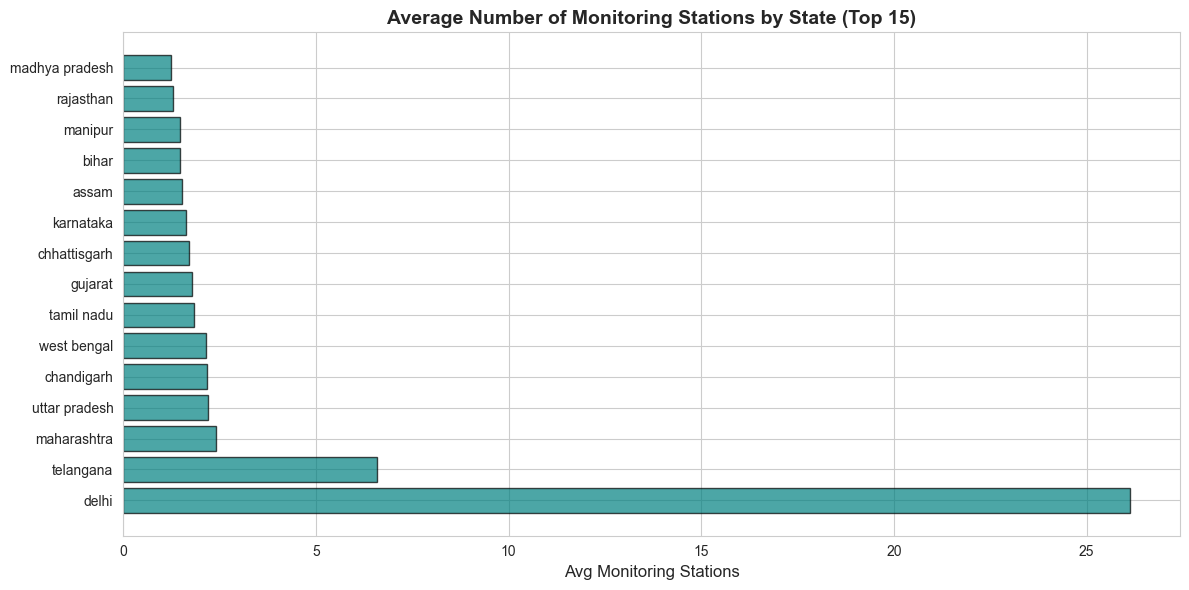


Top 15 States by Total Monitoring Stations:
 1. delhi                     -> 26
 2. telangana                 -> 6
 3. maharashtra               -> 2
 4. uttar pradesh             -> 2
 5. chandigarh                -> 2
 6. west bengal               -> 2
 7. tamil nadu                -> 1
 8. gujarat                   -> 1
 9. chhattisgarh              -> 1
10. karnataka                 -> 1
11. assam                     -> 1
12. bihar                     -> 1
13. manipur                   -> 1
14. rajasthan                 -> 1
15. madhya pradesh            -> 1


In [13]:
stations_by_state = data.groupby('state')['number_of_monitoring_stations'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(stations_by_state.index, stations_by_state.values, color='teal', edgecolor='black', alpha=0.7)
plt.title("Average Number of Monitoring Stations by State (Top 15)", fontsize=14, fontweight='bold')
plt.xlabel("Avg Monitoring Stations", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 15 States by Total Monitoring Stations:")
for rank, (state, value) in enumerate(stations_by_state.items(), 1):
    print(f"{rank:2d}. {state:25} -> {int(value)}")

## Key Findings Summary

In [11]:
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\n1. Top 5 Worst Performing States (Highest AQI):")
print(data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(5))

print("\n2. Top 5 Best Performing States (Lowest AQI):")
print(data.groupby('state')['aqi_value'].mean().sort_values(ascending=True).head(5))

print("\n3. Air Quality Status Breakdown:")
status_dist = data['air_quality_status'].value_counts()
for status, count in status_dist.items():
    print(f"   {status}: {count:,} ({count/len(data)*100:.1f}%)")

print("\n4. Quality Level by Status:")
for status in status_order:
    level = data[data['air_quality_status'] == status]['quality_level'].iloc[0] if status in data['air_quality_status'].values else "N/A"
    print(f"   {status}: Level {level}")

print("\n5. Peak Pollution Month:", data.groupby('month')['aqi_value'].mean().idxmax(), "(Avg AQI: {:.1f})".format(data.groupby('month')['aqi_value'].mean().max()))

print("\n6. Cleanest Month:", data.groupby('month')['aqi_value'].mean().idxmin(), "(Avg AQI: {:.1f})".format(data.groupby('month')['aqi_value'].mean().min()))

SUMMARY STATISTICS

1. Top 5 Worst Performing States (Highest AQI):
state
delhi               215.895080
bihar               165.905256
himachal pradesh    160.133040
uttar pradesh       159.542288
haryana             151.533731
Name: aqi_value, dtype: float64

2. Top 5 Best Performing States (Lowest AQI):
state
mizoram              45.059902
meghalaya            52.616343
sikkim               53.469505
puducherry           55.957572
arunachal pradesh    59.861194
Name: aqi_value, dtype: float64

3. Air Quality Status Breakdown:
   Satisfactory: 155,222 (36.5%)
   Moderate: 138,532 (32.6%)
   Good: 69,754 (16.4%)
   Poor: 43,812 (10.3%)
   Very Poor: 15,392 (3.6%)
   Severe: 2,567 (0.6%)

4. Quality Level by Status:
   Good: Level 1
   Satisfactory: Level 2
   Moderate: Level 3
   Poor: Level 4
   Very Poor: Level 5
   Severe: Level 6

5. Peak Pollution Month: 11 (Avg AQI: 174.3)

6. Cleanest Month: 8 (Avg AQI: 66.2)


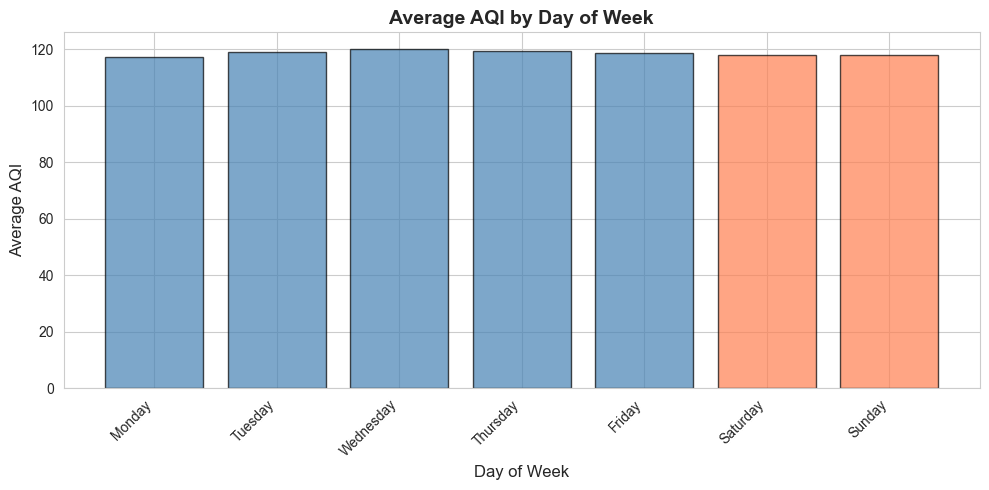

Average AQI by Day of Week:
day_of_week
Monday       117.412374
Tuesday      119.197181
Wednesday    119.991030
Thursday     119.483574
Friday       118.705045
Saturday     117.945781
Sunday       117.861407
Name: aqi_value, dtype: float64


In [12]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_aqi = data.groupby('day_of_week')['aqi_value'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
colors_day = ['steelblue' if i < 5 else 'coral' for i in range(7)]
plt.bar(range(7), day_aqi.values, color=colors_day, alpha=0.7, edgecolor='black')
plt.title("Average AQI by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average AQI", fontsize=12)
plt.xticks(range(7), day_order, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Average AQI by Day of Week:")
print(day_aqi)